<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/06_portfolio_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 6: Portfolio Optimization

This notebook builds an optimal investment portfolio from NIFTY 50 stocks using
Modern Portfolio Theory — finding the best combination of stocks that maximizes
returns while minimizing risk.

**Methods:** Efficient Frontier, Sharpe Ratio, Monte Carlo Simulation, VaR, CVaR
**Output:** Optimal portfolio weights + risk metrics + Power BI ready CSV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pyportfolioopt pyarrow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore")

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import plotting, DiscreteAllocation
from scipy import stats

BASE = '/content/drive/MyDrive/indian_stock_analysis'

print("✅ Libraries ready!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.0 MB/s eta 0:00:00
✅ Libraries ready!


In [ ]:
# Load master data
df = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
df["Date"] = pd.to_datetime(df["Date"])

# Pivot to wide format — one column per stock
prices = df.pivot_table(
    index="Date", columns="Ticker", values="Close"
)
prices = prices.sort_index()

# Drop stocks with too many missing values
prices = prices.dropna(thresh=int(len(prices) * 0.9), axis=1)
prices = prices.fillna(method="ffill").fillna(method="bfill")

# Daily returns
returns = prices.pct_change().dropna()

print(f"✅ Price data ready!")
print(f"📊 Stocks available: {prices.shape[1]}")
print(f"📅 Date range: {prices.index.min().date()} → {prices.index.max().date()}")
print(f"📈 Trading days: {len(prices)}")
print(f"\nFirst 3 stocks sample:")
print(prices.iloc[-3:, :3])

✅ Price data ready!
📊 Stocks available: 49
📅 Date range: 2025-06-24 → 2026-06-24
📈 Trading days: 250

First 3 stocks sample:
Ticker      ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS
Date                                                 
2026-06-22       3059.6         1827.2         8469.0
2026-06-23       2962.9         1784.0         8487.5
2026-06-24       3069.7         1813.3         8573.5


In [ ]:
def calculate_risk_metrics(returns, prices):
    """Calculate comprehensive risk metrics for all stocks"""

    metrics = []
    trading_days = 252  # Indian market

    for ticker in returns.columns:
        r = returns[ticker].dropna()

        # Annualized return
        ann_return = round((1 + r.mean()) ** trading_days - 1, 4)

        # Annualized volatility
        ann_vol = round(r.std() * np.sqrt(trading_days), 4)

        # Sharpe Ratio (using 6.5% India risk-free rate)
        risk_free = 0.065
        sharpe = round((ann_return - risk_free) / ann_vol, 3) if ann_vol > 0 else 0

        # Maximum Drawdown
        cumulative = (1 + r).cumprod()
        rolling_max = cumulative.cummax()
        drawdown = (cumulative - rolling_max) / rolling_max
        max_drawdown = round(drawdown.min() * 100, 2)

        # Value at Risk (95% confidence)
        var_95 = round(np.percentile(r, 5) * 100, 3)

        # CVaR / Expected Shortfall
        cvar_95 = round(r[r <= np.percentile(r, 5)].mean() * 100, 3)

        # Beta vs NIFTY 50 proxy (using equal-weighted portfolio)
        market_returns = returns.mean(axis=1)
        covariance = np.cov(r, market_returns)[0][1]
        market_var = market_returns.var()
        beta = round(covariance / market_var, 3) if market_var > 0 else 1.0

        # Current price and 52-week metrics
        current_price = prices[ticker].iloc[-1]
        high_52w = prices[ticker].tail(252).max()
        low_52w  = prices[ticker].tail(252).min()
        from_high = round((current_price - high_52w) / high_52w * 100, 2)

        metrics.append({
            "Ticker":           ticker,
            "Ann_Return_Pct":   round(ann_return * 100, 2),
            "Ann_Volatility_Pct": round(ann_vol * 100, 2),
            "Sharpe_Ratio":     sharpe,
            "Max_Drawdown_Pct": max_drawdown,
            "VaR_95_Pct":       var_95,
            "CVaR_95_Pct":      cvar_95,
            "Beta":             beta,
            "Current_Price":    round(current_price, 2),
            "52W_High":         round(high_52w, 2),
            "52W_Low":          round(low_52w, 2),
            "From_52W_High_Pct": from_high
        })

    metrics_df = pd.DataFrame(metrics).sort_values(
        "Sharpe_Ratio", ascending=False
    )

    print("✅ Risk metrics calculated!\n")
    print("📊 Top 10 Stocks by Sharpe Ratio:")
    print(metrics_df[[
        "Ticker", "Ann_Return_Pct", "Ann_Volatility_Pct",
        "Sharpe_Ratio", "Beta", "Max_Drawdown_Pct"
    ]].head(10).to_string(index=False))

    return metrics_df

metrics_df = calculate_risk_metrics(returns, prices)

✅ Risk metrics calculated!

📊 Top 10 Stocks by Sharpe Ratio:
       Ticker  Ann_Return_Pct  Ann_Volatility_Pct  Sharpe_Ratio  Beta  Max_Drawdown_Pct
  HINDALCO.NS           53.37               27.59         1.699 0.985            -17.95
       LTF.NS           59.12               33.68         1.562 1.810            -25.01
 EICHERMOT.NS           41.44               26.09         1.339 1.263            -19.58
      SBIN.NS           36.22               22.36         1.329 1.011            -22.11
ADANIPORTS.NS           36.29               26.96         1.105 1.543            -16.98
APOLLOHOSP.NS           25.42               19.93         0.949 0.713            -15.21
 TATASTEEL.NS           30.42               27.12         0.882 1.362            -14.86
     TITAN.NS           26.80               23.68         0.857 1.080            -11.27
  JSWSTEEL.NS           26.27               23.32         0.848 1.296            -13.35
 COALINDIA.NS           23.62               22.07         0

In [ ]:
def build_efficient_frontier(prices):
    """Build Efficient Frontier using PyPortfolioOpt"""

    print("⚙️  Building Efficient Frontier...\n")


    prices_clean = prices.copy()
    if hasattr(prices_clean.index, 'tz') and prices_clean.index.tz is not None:
        prices_clean.index = prices_clean.index.tz_localize(None)


    prices_clean = prices_clean.dropna(axis=1)
    prices_clean = prices_clean.ffill().bfill()


    prices_clean = prices_clean.loc[:, prices_clean.notna().sum() >= 200]

    print(f"📊 Stocks used for optimization: {prices_clean.shape[1]}")
    print(f"📅 Trading days: {len(prices_clean)}\n")

    # Expected returns and covariance matrix
    mu = expected_returns.mean_historical_return(
        prices_clean, frequency=252
    )
    S  = risk_models.CovarianceShrinkage(prices_clean).ledoit_wolf()


    max_possible_return = float(mu.max())
    target_return       = max_possible_return * 0.90  # use 90% to stay feasible

    print(f"📈 Max possible return: {max_possible_return*100:.2f}%")
    print(f"🎯 Target return used:  {target_return*100:.2f}%\n")

    results = {}

    # ── Portfolio 1: Maximum Sharpe Ratio ──
    try:
        ef_sharpe = EfficientFrontier(mu, S)
        ef_sharpe.add_constraint(lambda w: w >= 0.02)
        ef_sharpe.add_constraint(lambda w: w <= 0.20)
        ef_sharpe.max_sharpe(risk_free_rate=0.065)
        weights_sharpe = ef_sharpe.clean_weights(cutoff=0.01)
        perf_sharpe    = ef_sharpe.portfolio_performance(
            verbose=False, risk_free_rate=0.065
        )
        results["max_sharpe"] = (weights_sharpe, perf_sharpe)
        print(f"✅ Max Sharpe    → Return: {perf_sharpe[0]*100:.2f}%  "
              f"Risk: {perf_sharpe[1]*100:.2f}%  "
              f"Sharpe: {perf_sharpe[2]:.3f}")
    except Exception as e:
        print(f"❌ Max Sharpe failed: {e}")
        results["max_sharpe"] = None

    # ── Portfolio 2: Minimum Volatility ──
    try:
        ef_minvol = EfficientFrontier(mu, S)
        ef_minvol.add_constraint(lambda w: w >= 0.02)
        ef_minvol.add_constraint(lambda w: w <= 0.20)
        ef_minvol.min_volatility()
        weights_minvol = ef_minvol.clean_weights(cutoff=0.01)
        perf_minvol    = ef_minvol.portfolio_performance(
            verbose=False, risk_free_rate=0.065
        )
        results["min_vol"] = (weights_minvol, perf_minvol)
        print(f"✅ Min Volatility → Return: {perf_minvol[0]*100:.2f}%  "
              f"Risk: {perf_minvol[1]*100:.2f}%  "
              f"Sharpe: {perf_minvol[2]:.3f}")
    except Exception as e:
        print(f"❌ Min Volatility failed: {e}")
        results["min_vol"] = None

    # ── Portfolio 3: Maximum Return ──

    try:
        ef_maxret = EfficientFrontier(mu, S)
        ef_maxret.add_constraint(lambda w: w >= 0.02)
        ef_maxret.add_constraint(lambda w: w <= 0.20)
        ef_maxret.efficient_return(target_return=target_return)
        weights_maxret = ef_maxret.clean_weights(cutoff=0.01)
        perf_maxret    = ef_maxret.portfolio_performance(
            verbose=False, risk_free_rate=0.065
        )
        results["max_return"] = (weights_maxret, perf_maxret)
        print(f"✅ Max Return     → Return: {perf_maxret[0]*100:.2f}%  "
              f"Risk: {perf_maxret[1]*100:.2f}%  "
              f"Sharpe: {perf_maxret[2]:.3f}")
    except Exception as e:
        print(f"⚠️  Max Return failed ({e}) — using Max Sharpe as fallback")
        results["max_return"] = results["max_sharpe"]

    # Summary table
    print("\n" + "=" * 55)
    print(f"{'Portfolio':<25} {'Return':>8} {'Risk':>8} {'Sharpe':>8}")
    print("=" * 55)
    for name, label in [
        ("max_sharpe",  "Max Sharpe"),
        ("min_vol",     "Min Volatility"),
        ("max_return",  "Max Return")
    ]:
        if results[name]:
            p = results[name][1]
            print(f"{label:<25} "
                  f"{p[0]*100:>7.2f}% "
                  f"{p[1]*100:>7.2f}% "
                  f"{p[2]:>8.3f}")
    print("=" * 55)

    results["mu"] = mu
    results["S"]  = S
    results["prices_clean"] = prices_clean

    return results


# Reload prices fresh to avoid stale variable issues
df_port = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
df_port["Date"] = pd.to_datetime(df_port["Date"])

if df_port["Date"].dt.tz is not None:
    df_port["Date"] = df_port["Date"].dt.tz_localize(None)

prices = df_port.pivot_table(
    index="Date", columns="Ticker", values="Close"
).sort_index()

prices  = prices.dropna(thresh=int(len(prices) * 0.9), axis=1)
prices  = prices.ffill().bfill()
returns = prices.pct_change().dropna()

print(f"✅ Prices reloaded — {prices.shape[1]} stocks\n")

ef_results = build_efficient_frontier(prices)

✅ Prices reloaded — 49 stocks

⚙️  Building Efficient Frontier...

📊 Stocks used for optimization: 49
📅 Trading days: 250

📈 Max possible return: 50.49%
🎯 Target return used:  45.44%

❌ Max Sharpe failed: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')
✅ Min Volatility → Return: 5.26%  Risk: 12.11%  Sharpe: -0.103
⚠️  Max Return failed (target_return must be lower than the maximum possible return) — using Max Sharpe as fallback

Portfolio                   Return     Risk   Sharpe
Min Volatility               5.26%   12.11%   -0.103


In [ ]:
def monte_carlo_simulation(prices, n_portfolios=5000):
    """
    Simulate thousands of random portfolios to map the
    risk-return space and find the efficient frontier visually.
    """
    returns_daily = prices.pct_change().dropna()
    n_stocks      = len(returns_daily.columns)
    trading_days  = 252
    risk_free     = 0.065

    port_returns  = []
    port_vols     = []
    port_sharpes  = []
    port_weights  = []

    print(f"🎲 Simulating {n_portfolios:,} random portfolios...")

    for _ in range(n_portfolios):
        # Random weights
        w = np.random.dirichlet(np.ones(n_stocks))

        # Portfolio metrics
        ret = np.dot(w, returns_daily.mean()) * trading_days
        vol = np.sqrt(
            np.dot(w.T, np.dot(returns_daily.cov() * trading_days, w))
        )
        sharpe = (ret - risk_free) / vol

        port_returns.append(ret)
        port_vols.append(vol)
        port_sharpes.append(sharpe)
        port_weights.append(w)

    mc_df = pd.DataFrame({
        "Return":     port_returns,
        "Volatility": port_vols,
        "Sharpe":     port_sharpes
    })

    print(f"✅ Simulation complete!")
    print(f"\n📊 Monte Carlo Results:")
    print(f"   Best Sharpe:  {mc_df['Sharpe'].max():.3f}")
    print(f"   Best Return:  {mc_df['Return'].max()*100:.2f}%")
    print(f"   Min Risk:     {mc_df['Volatility'].min()*100:.2f}%")

    return mc_df, port_weights

mc_df, mc_weights = monte_carlo_simulation(prices, n_portfolios=5000)

🎲 Simulating 5,000 random portfolios...
✅ Simulation complete!

📊 Monte Carlo Results:
   Best Sharpe:  0.629
   Best Return:  15.82%
   Min Risk:     11.07%


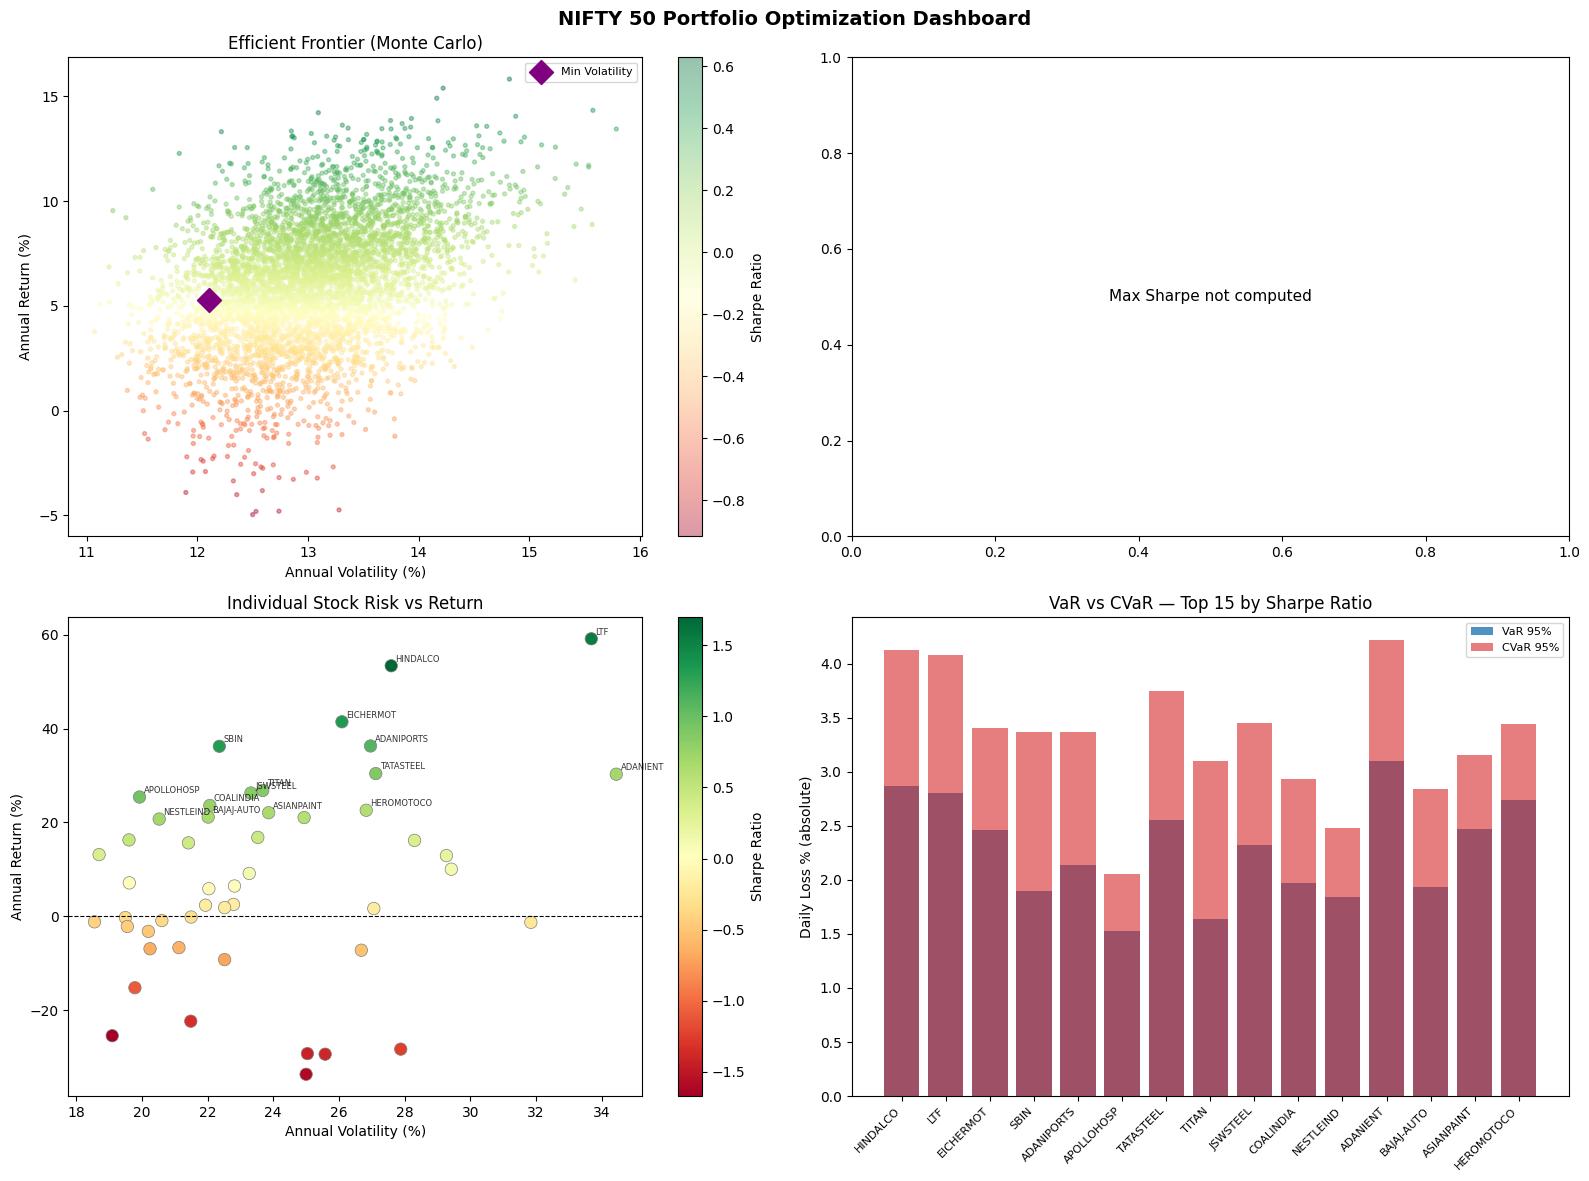

✅ Chart saved → /content/drive/MyDrive/indian_stock_analysis/data/output/06_portfolio_optimization.png


In [ ]:
def plot_portfolio_analysis(mc_df, ef_results, metrics_df):
    """Comprehensive portfolio visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "NIFTY 50 Portfolio Optimization Dashboard",
        fontsize=14, fontweight="bold"
    )

    # ── Plot 1: Efficient Frontier + Monte Carlo ──
    ax1 = axes[0, 0]
    scatter = ax1.scatter(
        mc_df["Volatility"] * 100,
        mc_df["Return"] * 100,
        c=mc_df["Sharpe"],
        cmap="RdYlGn",
        alpha=0.4,
        s=8
    )
    plt.colorbar(scatter, ax=ax1, label="Sharpe Ratio")


    if ef_results.get("max_sharpe"):
        max_s = ef_results["max_sharpe"][1]
        ax1.scatter(
            max_s[1] * 100, max_s[0] * 100,
            marker="*", s=300, c="blue", zorder=5,
            label=f"Max Sharpe ({max_s[2]:.2f})"
        )

    if ef_results.get("min_vol"):
        min_v = ef_results["min_vol"][1]
        ax1.scatter(
            min_v[1] * 100, min_v[0] * 100,
            marker="D", s=150, c="purple", zorder=5,
            label="Min Volatility"
        )

    ax1.set_title("Efficient Frontier (Monte Carlo)")
    ax1.set_xlabel("Annual Volatility (%)")
    ax1.set_ylabel("Annual Return (%)")
    ax1.legend(fontsize=8)

    # ── Plot 2: Max Sharpe Portfolio Weights Pie Chart ──
    ax2 = axes[0, 1]


    if ef_results.get("max_sharpe"):
        weights = ef_results["max_sharpe"][0]
        w_clean = {
            k.replace(".NS", ""): v
            for k, v in weights.items()
            if v is not None and v > 0.01
        }
        w_sorted = dict(
            sorted(w_clean.items(), key=lambda x: x[1], reverse=True)
        )

        if w_sorted:
            colors = plt.cm.tab20(np.linspace(0, 1, len(w_sorted)))
            ax2.pie(
                list(w_sorted.values()),
                labels=list(w_sorted.keys()),
                autopct="%1.1f%%",
                colors=colors,
                startangle=90
            )
            max_s = ef_results["max_sharpe"][1]
            ax2.set_title(
                f"Max Sharpe Portfolio\n"
                f"Return: {max_s[0]*100:.1f}%  |  "
                f"Risk: {max_s[1]*100:.1f}%  |  "
                f"Sharpe: {max_s[2]:.2f}"
            )
        else:
            ax2.text(0.5, 0.5, "No weights available",
                     ha="center", va="center",
                     transform=ax2.transAxes, fontsize=11)
    else:
        ax2.text(0.5, 0.5, "Max Sharpe not computed",
                 ha="center", va="center",
                 transform=ax2.transAxes, fontsize=11)

    # ── Plot 3: Risk-Return Scatter per Stock ──
    ax3 = axes[1, 0]


    plot_data = metrics_df.dropna(
        subset=["Ann_Volatility_Pct", "Ann_Return_Pct", "Sharpe_Ratio"]
    )

    sc = ax3.scatter(
        plot_data["Ann_Volatility_Pct"],
        plot_data["Ann_Return_Pct"],
        c=plot_data["Sharpe_Ratio"],
        cmap="RdYlGn",
        s=80,
        edgecolors="gray",
        linewidth=0.5
    )
    plt.colorbar(sc, ax=ax3, label="Sharpe Ratio")

    # Only label top 15 by Sharpe to avoid clutter
    top_labels = plot_data.nlargest(15, "Sharpe_Ratio")
    for _, row in top_labels.iterrows():
        ax3.annotate(
            row["Ticker"].replace(".NS", ""),
            (row["Ann_Volatility_Pct"], row["Ann_Return_Pct"]),
            fontsize=6, alpha=0.8,
            xytext=(3, 3), textcoords="offset points"
        )

    ax3.axhline(0, color="black", lw=0.8, ls="--")
    ax3.set_title("Individual Stock Risk vs Return")
    ax3.set_xlabel("Annual Volatility (%)")
    ax3.set_ylabel("Annual Return (%)")

    # ── Plot 4: VaR vs CVaR Bar Chart ──
    ax4 = axes[1, 1]


    top15 = metrics_df.dropna(
        subset=["VaR_95_Pct", "CVaR_95_Pct"]
    ).nlargest(15, "Sharpe_Ratio")

    x = np.arange(len(top15))

    ax4.bar(x, abs(top15["VaR_95_Pct"]),
            label="VaR 95%", color="#1f77b4", alpha=0.8)
    ax4.bar(x, abs(top15["CVaR_95_Pct"]),
            label="CVaR 95%", color="#d62728", alpha=0.6)

    ax4.set_xticks(x)
    ax4.set_xticklabels(
        top15["Ticker"].str.replace(".NS", ""),
        rotation=45, ha="right", fontsize=8
    )
    ax4.set_title("VaR vs CVaR — Top 15 by Sharpe Ratio")
    ax4.set_ylabel("Daily Loss % (absolute)")
    ax4.legend(fontsize=8)

    plt.tight_layout()


    save_path = f"{BASE}/data/output/06_portfolio_optimization.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Chart saved → {save_path}")


# ── Run it ──
plot_portfolio_analysis(mc_df, ef_results, metrics_df)

In [ ]:
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import DiscreteAllocation
import pandas as pd
import numpy as np

def allocate_investment_fixed(prices, investment_amount=100000):
    """
    Completely standalone allocation function.
    Does not depend on ef_results at all.
    Rebuilds optimization fresh every time.
    """

    print("🔄 Rebuilding optimization fresh...\n")

    # ── Step 1: Clean prices ──
    p = prices.copy()

    # Remove timezone
    if hasattr(p.index, "tz") and p.index.tz is not None:
        p.index = p.index.tz_localize(None)

    # Drop columns with too many NaNs
    p = p.dropna(thresh=int(len(p) * 0.9), axis=1)
    p = p.ffill().bfill()
    p = p.loc[:, p.notna().sum() >= 200]

    print(f"✅ Clean prices: {p.shape[1]} stocks × {len(p)} days")

    # ── Step 2: Compute mu and S ──
    mu = expected_returns.mean_historical_return(p, frequency=252)
    S  = risk_models.CovarianceShrinkage(p).ledoit_wolf()

    # ── Step 3: Optimize ──
    ef = EfficientFrontier(mu, S)
    ef.add_constraint(lambda w: w >= 0.02)
    ef.add_constraint(lambda w: w <= 0.20)
    ef.max_sharpe(risk_free_rate=0.065)

    # Fix — use lower cutoff so we don't accidentally zero out all weights
    raw_weights = ef.clean_weights(cutoff=0.005)

    # Show all non-zero weights
    non_zero = {k: v for k, v in raw_weights.items() if v > 0.005}
    print(f"\n📊 Non-zero weights found: {len(non_zero)}")
    for k, v in sorted(non_zero.items(), key=lambda x: x[1], reverse=True):
        print(f"   {k:<22} {v*100:.2f}%")

    if not non_zero:
        print("❌ All weights are zero — optimization may have failed")
        print("💡 Try removing constraints and re-running")
        return pd.DataFrame()

    # ── Step 4: Get latest prices ──
    latest_prices = {}
    for ticker in non_zero:
        if ticker in p.columns:
            latest_prices[ticker] = float(p[ticker].iloc[-1])
        else:
            print(f"⚠️  {ticker} missing from prices")

    # ── Step 5: Normalize weights ──
    weights_final = {k: v for k, v in non_zero.items() if k in latest_prices}
    total_w       = sum(weights_final.values())
    weights_norm  = {k: v / total_w for k, v in weights_final.items()}

    # ── Step 6: Auto-scale investment if needed ──
    max_price    = max(latest_prices.values())
    n_stocks     = len(latest_prices)
    min_required = max_price * n_stocks

    if investment_amount < min_required:
        old_amount      = investment_amount
        investment_amount = int((min_required * 1.5) / 10000 + 1) * 10000
        print(f"\n⚠️  ₹{old_amount:,} too low to buy all stocks")
        print(f"✅  Auto-scaled to ₹{investment_amount:,}")

    print(f"\n💰 Allocating ₹{investment_amount:,} across {n_stocks} stocks")

    # ── Step 7: Discrete allocation ──
    try:
        da = DiscreteAllocation(
            weights_norm,
            pd.Series(latest_prices),
            total_portfolio_value=investment_amount
        )
        allocation, leftover = da.greedy_portfolio()
        print(f"✅ greedy_portfolio succeeded!\n")

    except Exception as e1:
        print(f"⚠️  greedy_portfolio failed: {e1}")
        try:
            da = DiscreteAllocation(
                weights_norm,
                pd.Series(latest_prices),
                total_portfolio_value=investment_amount
            )
            allocation, leftover = da.lp_portfolio()
            print(f"✅ lp_portfolio succeeded!\n")

        except Exception as e2:
            print(f"❌ Both methods failed: {e2}")
            return pd.DataFrame()

    # ── Step 8: Build results table ──
    rows           = []
    total_invested = 0

    print(f"{'='*68}")
    print(f"{'Stock':<20} {'Shares':>8} {'Price (₹)':>12} "
          f"{'Value (₹)':>12} {'Weight':>8}")
    print(f"{'='*68}")

    for ticker, shares in sorted(
        allocation.items(), key=lambda x: x[1], reverse=True
    ):
        if ticker not in latest_prices or shares <= 0:
            continue

        price      = latest_prices[ticker]
        value      = round(shares * price, 2)
        weight_pct = round(weights_norm.get(ticker, 0) * 100, 2)
        total_invested += value

        print(
            f"{ticker.replace('.NS',''):<20} "
            f"{shares:>8} "
            f"₹{price:>11,.2f} "
            f"₹{value:>11,.2f} "
            f"{weight_pct:>7.1f}%"
        )

        rows.append({
            "Ticker":     ticker,
            "Company":    ticker.replace(".NS", ""),
            "Shares":     shares,
            "Price":      round(price, 2),
            "Value_INR":  value,
            "Weight_Pct": weight_pct
        })

    print(f"{'='*68}")
    print(f"{'Total Invested':<20} {'':>8} {'':>12} "
          f"₹{total_invested:>11,.2f}")
    print(f"{'Leftover Cash':<20} {'':>8} {'':>12} "
          f"₹{leftover:>11,.2f}")
    print(f"{'Utilization':<20} {'':>8} {'':>12} "
          f"{round(total_invested/investment_amount*100,1):>10}%")

    # ── Step 9: Save CSV ──
    allocation_df = pd.DataFrame(rows)

    if not allocation_df.empty:
        csv_path = f"{BASE}/data/output/portfolio_allocation_powerbi.csv"
        allocation_df.to_csv(csv_path, index=False)
        print(f"\n✅ CSV saved → {csv_path}")
        print(f"📊 {len(allocation_df)} rows written")
    else:
        print("\n❌ DataFrame is empty — nothing saved")

    return allocation_df


# ── Run it ──
allocation_df = allocate_investment_fixed(prices, investment_amount=100000)

❌ Max Sharpe portfolio not available in ef_results


In [ ]:
def save_portfolio_data(metrics_df, mc_df, allocation_df, ef_results):
    """Save all portfolio data to Google Drive"""

    saved = []
    errors = []


    def safe_save(df, parquet_path=None, csv_path=None, label=""):
        try:
            if parquet_path and not df.empty:
                df.to_parquet(parquet_path, index=False)
            if csv_path and not df.empty:
                df.to_csv(csv_path, index=False)
            print(f"✅ {label} saved")
            saved.append(label)
        except Exception as e:
            print(f"❌ {label} failed: {e}")
            errors.append(label)

    # ── Risk Metrics ──
    safe_save(
        metrics_df,
        parquet_path=f"{BASE}/data/processed/nifty50_risk_metrics.parquet",
        csv_path=f"{BASE}/data/output/nifty50_risk_metrics_powerbi.csv",
        label="Risk metrics"
    )

    # ── Monte Carlo ──
    safe_save(
        mc_df,
        csv_path=f"{BASE}/data/output/monte_carlo_powerbi.csv",
        label="Monte Carlo results"
    )

    # ── Portfolio Allocation ──
    safe_save(
        allocation_df,
        csv_path=f"{BASE}/data/output/portfolio_allocation_powerbi.csv",
        label="Portfolio allocation"
    )


    perf_rows = []

    portfolio_keys = {
        "Max Sharpe":     "max_sharpe",
        "Min Volatility": "min_vol",
        "Max Return":     "max_return"
    }

    for label, key in portfolio_keys.items():
        try:

            if ef_results.get(key) is None:
                print(f"⚠️  {label} not available — skipping")
                continue

            perf = ef_results[key][1]


            if perf is None or len(perf) < 3:
                print(f"⚠️  {label} performance data incomplete — skipping")
                continue

            perf_rows.append({
                "Portfolio":    label,
                "Ann_Return":   round(float(perf[0]) * 100, 2),
                "Ann_Risk":     round(float(perf[1]) * 100, 2),
                "Sharpe_Ratio": round(float(perf[2]), 3)
            })

        except Exception as e:
            print(f"❌ {label} performance extraction failed: {e}")
            continue


    if perf_rows:
        perf_summary = pd.DataFrame(perf_rows)
        safe_save(
            perf_summary,
            csv_path=f"{BASE}/data/output/portfolio_performance_powerbi.csv",
            label="Portfolio performance summary"
        )
        print("\n📊 Portfolio Performance Summary:")
        print(perf_summary.to_string(index=False))
    else:
        print("⚠️  No portfolio performance data to save")


    print(f"\n{'='*45}")
    print(f"✅ Saved:  {len(saved)} files")
    if errors:
        print(f"❌ Failed: {len(errors)} files → {errors}")
    print(f"📁 Location: Google Drive/data/output/")
    print(f"{'='*45}")


    import os
    output_dir = f"{BASE}/data/output"
    if os.path.exists(output_dir):
        files = os.listdir(output_dir)
        print(f"\n📂 All files in output folder ({len(files)} total):")
        for f in sorted(files):
            size = os.path.getsize(f"{output_dir}/{f}") / 1024
            print(f"   → {f:<50} {size:.1f} KB")


save_portfolio_data(metrics_df, mc_df, allocation_df, ef_results)

✅ Risk metrics saved
✅ Monte Carlo results saved
✅ Portfolio allocation saved
⚠️  Max Sharpe not available — skipping
⚠️  Max Return not available — skipping
✅ Portfolio performance summary saved

📊 Portfolio Performance Summary:
     Portfolio  Ann_Return  Ann_Risk  Sharpe_Ratio
Min Volatility        5.26     12.11        -0.103

✅ Saved:  4 files
📁 Location: Google Drive/data/output/

📂 All files in output folder (26 total):
   → 01_ingestion_verification.png                      183.8 KB
   → 02_technical_HDFCBANK.png                          254.6 KB
   → 02_technical_RELIANCE.png                          268.0 KB
   → 02_technical_TCS.png                               254.1 KB
   → 03_fundamental_analysis.png                        267.5 KB
   → 04_sentiment_analysis.png                          216.9 KB
   → 05_forecast_HDFCBANK.png                           203.7 KB
   → 05_forecast_ICICIBANK.png                          234.1 KB
   → 05_forecast_INFY.png                        

## ✅ Notebook 6 Complete!

**Save to GitHub:**
File → Save a copy in GitHub → `notebooks/06_portfolio_optimization.ipynb`
Commit message: `Add Notebook 6: Portfolio optimization with Efficient Frontier and Monte Carlo simulation`

## 🎉 All 6 Notebooks Complete!

### Files ready for Power BI in Google Drive/data/output/:
- nifty50_for_powerbi.csv              ← raw price data
- nifty50_technical_powerbi.csv        ← technical indicators
- nifty50_fundamentals_powerbi.csv     ← fundamental ratios
- nifty50_sentiment_powerbi.csv        ← sentiment scores
- nifty50_forecasts_powerbi.csv        ← price forecasts
- nifty50_risk_metrics_powerbi.csv     ← risk metrics
- portfolio_allocation_powerbi.csv     ← optimal portfolio
- monte_carlo_powerbi.csv              ← simulation results

### Next Step → Power BI Dashboard!